In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

In [12]:

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return torch.relu(self.bn(self.conv(x)))

DROPOUT = 0.0
class InceptionBlock(nn.Module):
    def __init__(
        self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool
    ):
        super().__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1),
        )
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1),
        )

    def forward(self, x):
        branches = (self.branch1, self.branch2, self.branch3, self.branch4)
        return torch.cat([branch(x) for branch in branches], 1)


class InceptionModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = ConvBlock(3, 32, kernel_size=3, stride=2, padding=1)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = ConvBlock(32, 64, kernel_size=3, stride=1, padding=1)

        self.incept3a = InceptionBlock(64, 32, 32, 64, 16, 32, 32)
        self.incept3b = InceptionBlock(160, 64, 64, 96, 32, 64, 64)

        self.incept4a = InceptionBlock(288, 96, 64, 128, 32, 64, 64)
        self.incept4b = InceptionBlock(352, 96, 64, 128, 32, 64, 64)

        self.incept5a = InceptionBlock(352, 128, 96, 160, 32, 96, 96)

        self.dropout = nn.Dropout(p=DROPOUT)
        self.fc = nn.Linear(480, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        x = self.conv2(x)
        x = self.maxpool(x)

        x = self.incept3a(x)
        x = self.incept3b(x)
        x = self.maxpool(x)

        x = self.incept4a(x)
        x = self.incept4b(x)
        x = self.maxpool(x)

        x = self.incept5a(x)

        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        x = torch.sigmoid(x)
        return x


In [ ]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import display, clear_output

# video_path = "/home/toru2/Amara/Deep_learning/dl_lab345.ipynb/video/test.mov"

# IN_W, IN_H = 218, 178
# TARGET_AR = IN_W / IN_H  # 178/218

# def make_bbox_aspect(cx, cy, bw, bh, target_ar, scale=1.35):
#     bw *= scale
#     bh *= scale

#     cur_ar = bw / bh
#     if cur_ar > target_ar:
#         bh = bw / target_ar
#     else:
#         bw = bh * target_ar

#     x1 = cx - bw / 2.0
#     y1 = cy - bh / 2.0
#     x2 = cx + bw / 2.0
#     y2 = cy + bh / 2.0
#     return x1, y1, x2, y2

# def clip_box(x1, y1, x2, y2, W, H):
#     x1 = max(0, int(round(x1)))
#     y1 = max(0, int(round(y1)))
#     x2 = min(W, int(round(x2)))
#     y2 = min(H, int(round(y2)))
#     return x1, y1, x2, y2

# face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
# cap = cv2.VideoCapture(video_path)

# if not cap.isOpened():
#     raise RuntimeError(f"Could not open video: {video_path}")

# plt.figure(figsize=(6, 7))
# frame_idx = 0

# while True:
#     ok, frame = cap.read()
#     if not ok:
#         break

#     frame_idx += 1
#     H, W = frame.shape[:2]

#     gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#     faces = face_detector.detectMultiScale(
#         gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
#     )

#     if len(faces) == 0:
#         continue

#     x, y, fw, fh = sorted( x = torch.sigmoid(x) faces, key=lambda b: b[2] * b[3], reverse=True)[0]
#     cx = x + fw / 2.0
#     cy = y + fh / 2.0

#     fx1, fy1, fx2, fy2 = make_bbox_aspect(cx, cy, fw, fh, TARGET_AR, scale=1.35)
#     x1, y1, x2, y2 = clip_box(fx1, fy1, fx2, fy2, W, H)

#     crop = frame[y1:y2, x1:x2]
#     if crop.size == 0 or (x2 - x1) < 10 or (y2 - y1) < 10:
#         continue

#     raw_h, raw_w = crop.shape[:2]
#     crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
#     crop_resized = cv2.resize(crop_rgb, (IN_W, IN_H), interpolation=cv2.INTER_LINEAR)
#     rz_h, rz_w = crop_resized.shape[:2]

#     is_ok_resize = (rz_w == IN_W and rz_h == IN_H)
#     ar_raw = raw_w / max(raw_h, 1)

#     if frame_idx % 20 == 0:
#         print(
#             f"[{frame_idx}] raw={raw_w}x{raw_h}, raw_ar={ar_raw:.4f}, "
#             f"resized={rz_w}x{rz_h}, resized_ok={is_ok_resize}"
#         )

#     clear_output(wait=True)
#     plt.imshow(crop_resized)
#     plt.title(
#         f"raw: {raw_w}x{raw_h}  ar:{ar_raw:.4f}  -> resized: {rz_w}x{rz_h}  ok:{is_ok_resize}"
#     )
#     plt.axis("off")
#     display(plt.gcf())

# cap.release()
# clear_output(wait=True)
# print("Done: crop-size check completed.")

In [27]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DROPOUT = 0.0
model = InceptionModel(num_classes=10).to(device)
ckpt = torch.load(
    "/home/toru2/Amara/Deep_learning/dl_lab345.ipynb/checkpoints_landmarks3/epoch_040.pt",
    map_location=device,
)

state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
model.load_state_dict(state, strict=True)
model.eval()

video_path = "/home/toru2/Amara/Deep_learning/dl_lab345.ipynb/video/test1.mov"

# Training images are CelebA aligned faces at 178x218 (W x H).
IN_W, IN_H = 178, 218
TARGET_AR = IN_W / IN_H

def make_bbox_aspect(cx, cy, bw, bh, target_ar, scale=1.6):
    """Make bbox with fixed aspect ratio, centered at (cx, cy)."""
    bw *= scale
    bh *= scale

    cur_ar = bw / max(bh, 1e-6)
    if cur_ar > target_ar:
        bh = bw / target_ar
    else:
        bw = bh * target_ar

    x1 = cx - bw / 2.0
    y1 = cy - bh / 2.0
    x2 = cx + bw / 2.0
    y2 = cy + bh / 2.0
    return x1, y1, x2, y2

def clip_box(x1, y1, x2, y2, W, H):
    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(W, int(round(x2)))
    y2 = min(H, int(round(y2)))
    return x1, y1, x2, y2

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
 )

def _largest_face(gray):
    faces = face_detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )
    if len(faces) == 0:
        return None
    return sorted(faces, key=lambda b: b[2] * b[3], reverse=True)[0]

def crop_and_resize_face(frame_bgr, scale=1.6):
    """Returns (bbox_xyxy, face_resized_rgb) or None if no valid crop."""
    H, W = frame_bgr.shape[:2]
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    face = _largest_face(gray)
    if face is None:
        return None

    x, y, fw, fh = face
    cx = x + fw / 2.0
    cy = y + fh / 2.0

    fx1, fy1, fx2, fy2 = make_bbox_aspect(cx, cy, fw, fh, TARGET_AR, scale=scale)
    x1, y1, x2, y2 = clip_box(fx1, fy1, fx2, fy2, W, H)

    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0 or (x2 - x1) < 10 or (y2 - y1) < 10:
        return None

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    face_resized_rgb = cv2.resize(
        crop_rgb, (IN_W, IN_H), interpolation=cv2.INTER_LINEAR
    )
    return (x1, y1, x2, y2), face_resized_rgb

@torch.no_grad()
def predict_landmarks(face_resized_rgb):
    """Returns landmarks in normalized crop coords: shape (5, 2) in [0, 1]."""
    inp = torch.from_numpy(face_resized_rgb).permute(2, 0, 1).float() / 255.0
    inp = inp.unsqueeze(0).to(device)
    pred = model(inp)[0].detach().cpu().numpy()  # (10,)
    return np.clip(pred, 0.0, 1.0).reshape(-1, 2)

def draw_landmarks(frame_bgr, bbox_xyxy, pred_norm, color=(0, 255, 0)):
    x1, y1, x2, y2 = bbox_xyxy
    crop_w = (x2 - x1)
    crop_h = (y2 - y1)

    for px, py in pred_norm:
        gx = int(x1 + px * crop_w)
        gy = int(y1 + py * crop_h)
        cv2.circle(frame_bgr, (gx, gy), 3, color, -1)

    cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (255, 200, 0), 2)
    return frame_bgr

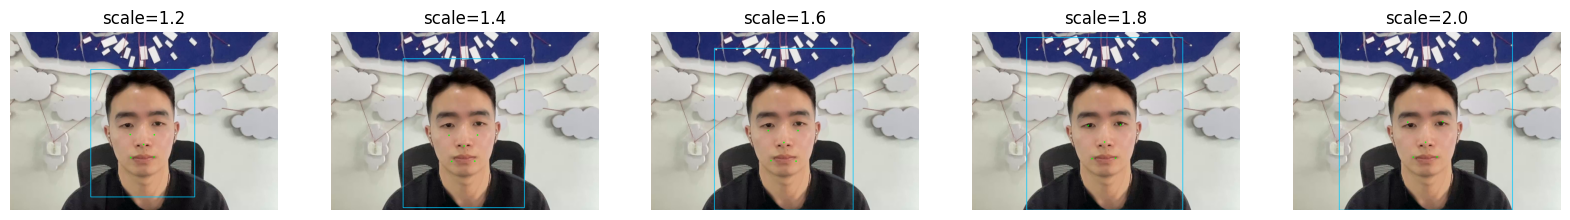

In [20]:
# Debug 1: check if crop scale is causing systematic landmark shift (especially eyes).

scales = [1.2, 1.4, 1.6, 1.8, 2.0]

cap = cv2.VideoCapture(video_path)
ok, frame0 = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f"Could not read first frame from: {video_path}")

fig, axes = plt.subplots(1, len(scales), figsize=(4 * len(scales), 4))
if len(scales) == 1:
    axes = [axes]

for ax, sc in zip(axes, scales):
    res = crop_and_resize_face(frame0, scale=sc)
    if res is None:
        ax.set_title(f"scale={sc}\nno face")
        ax.axis("off")
        continue
    bbox, face_resized = res
    pred = predict_landmarks(face_resized)
    vis = frame0.copy()
    draw_landmarks(vis, bbox, pred)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"scale={sc}")
    ax.axis("off")

plt.show()

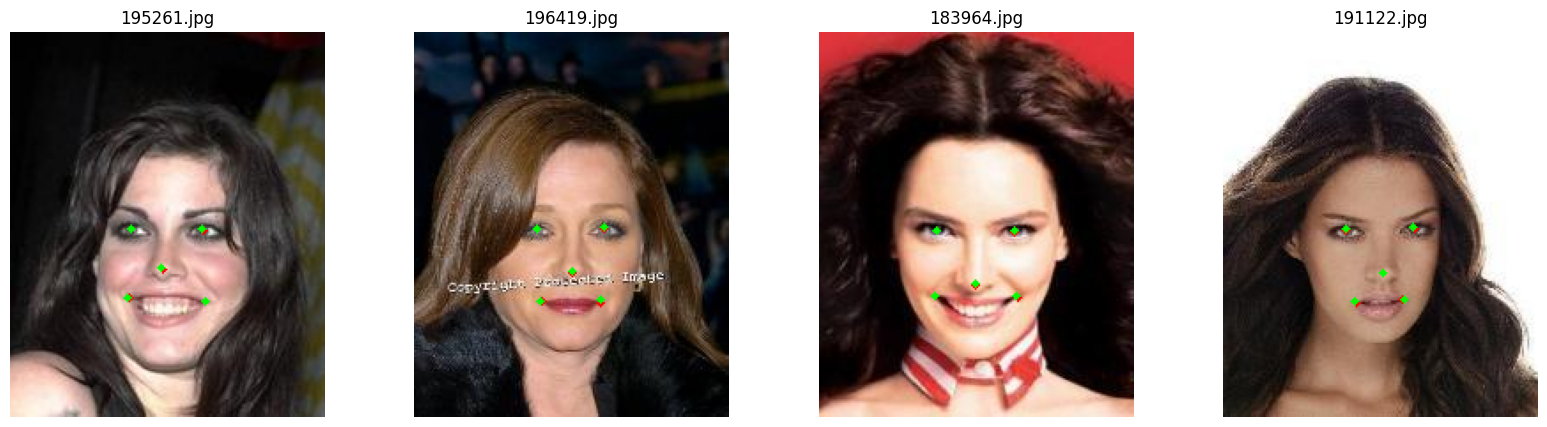

In [21]:
# Debug 2: sanity-check on CelebA aligned test images (in-domain).
# If eyes are correct here but wrong on video, the issue is almost certainly crop/alignment domain shift.

import random
from pathlib import Path
from PIL import Image

data_root = Path("/home/toru2/Amara/Deep_learning/dl_lab345.ipynb/dataset")
img_dir = data_root / "img_align_celeba"
partition_file = data_root / "list_eval_partition.txt"
landmark_file = data_root / "landmarks" / "list_landmarks_align_celeba.txt"

# Build partition map
partition = {}
with open(partition_file, "r") as f:
    for line in f:
        name, p = line.strip().split()
        partition[name] = int(p)

# Collect a few test samples
samples = []
with open(landmark_file, "r") as f:
    lines = f.readlines()[2:]  # skip header
for line in lines:
    parts = line.strip().split()
    name = parts[0]
    if partition.get(name, -1) != 2:
        continue
    coords = list(map(float, parts[1:]))
    samples.append((name, coords))

if len(samples) == 0:
    raise RuntimeError("No test samples found; check dataset paths.")

random.seed(0)
pick = random.sample(samples, k=min(4, len(samples)))

fig, axes = plt.subplots(1, len(pick), figsize=(5 * len(pick), 5))
if len(pick) == 1:
    axes = [axes]

for ax, (name, coords) in zip(axes, pick):
    img = Image.open(img_dir / name).convert("RGB")
    w, h = img.size
    arr_rgb = np.array(img)
    inp = torch.from_numpy(arr_rgb).permute(2, 0, 1).float() / 255.0
    inp = inp.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(inp)[0].detach().cpu().numpy().reshape(-1, 2)
    pred = np.clip(pred, 0.0, 1.0)

    vis_bgr = cv2.cvtColor(arr_rgb, cv2.COLOR_RGB2BGR)

    gt = np.array(coords, dtype=np.float32).reshape(-1, 2)
    # Ground truth in red
    for gx, gy in gt:
        cv2.circle(vis_bgr, (int(gx), int(gy)), 2, (0, 0, 255), -1)

    # Prediction in green
    for px, py in pred:
        cx = int(px * w)
        cy = int(py * h)
        cv2.circle(vis_bgr, (cx, cy), 2, (0, 255, 0), -1)

    ax.imshow(cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis("off")

plt.show()

KeyboardInterrupt: 

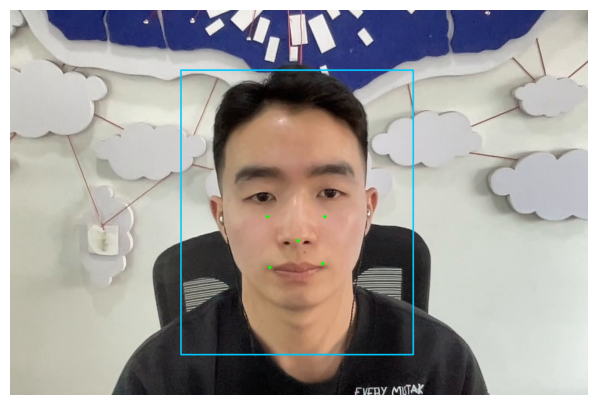

In [28]:
# Run: video inference (set SCALE based on Debug 1).

SCALE = 1.2  # try increasing if eye points are below the eyes
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

plt.figure(figsize=(8, 5))

while True:
    ok, frame = cap.read()
    if not ok:
        break

    res = crop_and_resize_face(frame, scale=SCALE)
    if res is not None:
        bbox, face_resized = res
        pred = predict_landmarks(face_resized)
        draw_landmarks(frame, bbox, pred)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.imshow(rgb)
    plt.axis("off")
    display(plt.gcf())

cap.release()
clear_output(wait=True)
print("Done.")